In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Algorithm
from sklearn.naive_bayes import MultinomialNB

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

In [73]:
df = pd.read_csv('E:/Courses/DS/Dataset/movie_review.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Text Cleaning

In [74]:
def cleanText(text):
    # to remove html element
    text = re.sub(r'<.*?>', '', text)
    # to remove all characters except alphabets
    text = re.sub(r'[^A-Za-z]', ' ', text)
    # to remove whitespace
    text = re.sub(r'\s+', ' ', text)
    return text

In [75]:
df['review'] = df['review'].apply(cleanText)

In [76]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production The filming tech...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there s a family where a little boy ...,negative
4,Petter Mattei s Love in the Time of Money is a...,positive


## Feature and Target

In [77]:
x = df['review']
y = df['sentiment']

In [78]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [79]:
# Creating custom set
stopwords = {'like', 'do', 'not', "don't", 'never', 'beautiful'}
custom_stop_words = list(set(ENGLISH_STOP_WORDS) - stopwords)

In [80]:
# Creating Dictionary of data
tfidf = TfidfVectorizer(
    lowercase = True,
    stop_words = custom_stop_words,
    ngram_range = (1,2)
)

In [81]:
# i do not like this movie.

# i do -> positive 
# do not -> negative
# not like -> negative
# like this -> positive
# this movie -> positive
# movie i -> positive

# result = negative (if any one is negative)


In [82]:
# common_words = vector()
# unique words = vector()

In [83]:
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

## Define Model

In [84]:
model = MultinomialNB()

In [85]:
model.fit(x_train_tfidf, y_train)
y_pred = model.predict(x_test_tfidf)

## Metics

In [86]:
cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [87]:
print(cr)

              precision    recall  f1-score   support

    negative       0.88      0.90      0.89      5000
    positive       0.89      0.87      0.88      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [88]:
print(cm)

[[4486  514]
 [ 626 4374]]


## Visualization

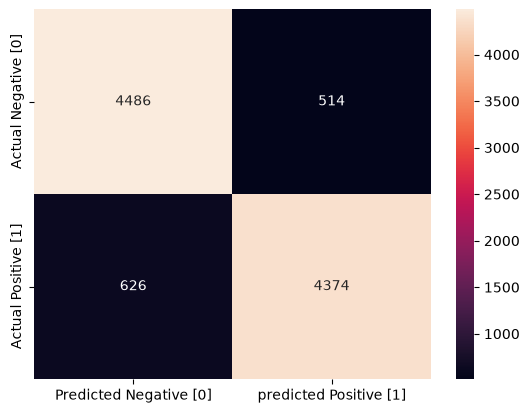

In [89]:
sns.heatmap(
    cm, annot = True, 
    fmt = '1.0f', 
    xticklabels=['Predicted Negative [0]','predicted Positive [1]'],
    yticklabels=['Actual Negative [0]', 'Actual Positive [1]'])
plt.show()

## New Data Prediction

In [90]:
def predictReview(text):
    cleaned_text = cleanText(text)
    cleaned_tfidf = tfidf.transform([cleaned_text])
    prediction = model.predict(cleaned_tfidf)[0]
    return prediction

In [93]:
review = input('Enter your movie review : ')
predictReview(review)

np.str_('negative')